# Klasifikasi Spasial Lahan Sawah dan Non-Sawah Menggunakan Citra Sentinel-2A

Bagian ini mendokumentasikan tahapan akuisisi citra satelit optik **Sentinel-2A (Level-2A)** dalam format GeoTIFF (`.tif`) melalui **openEO**, ekstraksi nilai spektral pada **100 titik sampel** (50 sampel Sawah dan 50 sampel Non-Sawah) yang telah dilabeli melalui **QGIS**, hingga pemodelan klasifikasi biner (2 kelas).

## Instalasi Library Yang Digunakan

In [15]:
pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.3/33.3 MB 101.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 8.6 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [geopandas]/3 [geopandas]
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: pandas0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [wrapt]
    Found existing installation: pandas 3.0.3━━━━━━━━━━━━━━━━━ 1/7 [wrapt]
    Uninstalling pandas-3.0.3:╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [pandas]
      Successfully uninstalled pandas-3.0.3m━━━━━━━━━━━━━━━━━━━━━━ 3/7 [pandas]
  Attempting uninstall: xarray╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [pandas]
    Found existing installation: xarray 2026.4.0━━━━━━━━━━━━━━ 3/7 [pandas]
    Uninstalling xarray-2026.4.0:0m━━━━━━━━━━━━━━━━━━━━━━ 3/7 [pandas]
      Successfully uninstalled xarray-2026.4.0━━━━━━━━━━━ 5/7 [xarray]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [openeo]2m6/7 [openeo]
Note: you may need to restart the kernel to use updated packages.


In [25]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## 1. Desain Pengambilan Sampel (Ground Truth)

Pengambilan sampel dilakukan secara spasial dengan membagi objek pengamatan ke dalam dua kelas seimbang (*balanced dataset*) dalam format vektor (`Shapefile` / `GeoJSON`):

| Kelas Target | Kode Label | Jumlah Sampel | Karakteristik Objek |
| :--- | :---: | :---: | :--- |
| **Sawah** | `1` | 50 Sampel | Petak lahan pertanian padi aktif (fase vegetatif, genangan air/tanam, maupun pematangan) |
| **Non-Sawah** | `0` | 50 Sampel | Permukiman/bangunan, jalan raya, badan air permanen, dan vegetasi non-pertanian |
| **Total** | — | **100 Sampel** | Digabungkan menjadi satu *GeoDataFrame* berproyeksi `EPSG:4326` |

In [20]:
import geopandas as gpd
import openeo
import pandas as pd

# ==============================================================================
# 1. BACA KEDUA FILE ZIP (SAWAH & NON-SAWAH) DAN BERI LABEL OTOMATIS
# ==============================================================================
# Sesuaikan nama file zip non-sawah milikmu di baris kedua
gdf_sawah = gpd.read_file("mystorage/sawah.zip").to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file("mystorage/non-sawah.zip").to_crs("EPSG:4326")

# Beri kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

# Gabungkan keduanya menjadi 1 GeoDataFrame (50 + 50 = 100 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & UNDUH SENTINEL-2A FORMAT GEOTIFF (.tif)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# Unduh menjadi file GeoTIFF (.tif)
nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")

Jumlah sampel Sawah     : 50
Jumlah sampel Non-Sawah : 50
Total sampel gabungan   : 100
Bounding Box Gabungan: {'west': 111.87169010000001, 'south': -6.9056517, 'east': 111.8930379, 'north': -6.8848906}
Authenticated using refresh token.
Mengunduh citra Sentinel-2A (.tif)...
Berhasil diunduh: sentinel2_sawah_nonsawah.tif


## 2. Akuisisi Citra Sentinel-2A (`.tif`) via openEO dan Ekstraksi Fitur

Akuisisi citra dilakukan menggunakan *bounding box* gabungan dari ke-100 titik sampel pada koleksi **`SENTINEL2_L2A`** (*Bottom-of-Atmosphere Reflectance*) dengan batas tutupan awan maksimum `< 10%` dan agregasi temporal `median_time()` untuk menghasilkan komposit citra bebas awan berformat **GeoTIFF (`.tif`)**.

### Fitur Spektral dan Indeks Turunan yang Diekstrak:
1. **Band Spektral Utama:**
   * `B02` (*Blue* - 490 nm), `B03` (*Green* - 560 nm), `B04` (*Red* - 665 nm) dengan resolusi spasial 10 meter.
   * `B08` (*Near Infrared / NIR* - 842 nm) untuk mendeteksi pantulan klorofil tanaman padi.
   * `B11` (*Short-Wave Infrared / SWIR* - 1610 nm) untuk mendeteksi kelembapan tanah dan genangan air.
2. **Normalized Difference Vegetation Index (NDVI):**

   $$\text{NDVI} = \frac{B08 - B04}{B08 + B04}$$

3. **Normalized Difference Water Index (NDWI):**

   $$\text{NDWI} = \frac{B03 - B08}{B03 + B08}$$

In [26]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())

# ==============================================================================
# 5. PROSES KLASIFIKASI 2 KELAS (SAWAH VS NON-SAWAH)
# ==============================================================================
fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training (40 Sawah + 40 Non-Sawah) & 20% Testing (10 Sawah + 10 Non-Sawah)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluasi pada data uji
y_pred = model_rf.predict(X_test)
print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)
print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/opt/conda/envs/esa-snap/lib/python3.12/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 2] No such file or directory.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'


/tmp/ipykernel_220/276632000.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
/tmp/ipykernel_220/276632000.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,725,1053,1395,2864,3501,0.344917,-0.462344,111.877677,-6.897550,Sawah,1
1,549,784,1080,2622,3034,0.416532,-0.539636,111.877841,-6.897592,Sawah,1
2,536,952,1107,2866,2877,0.442738,-0.501310,111.877975,-6.897645,Sawah,1
3,729,1147,1469,2971,3811,0.338288,-0.442933,111.877620,-6.897741,Sawah,1
4,652,950,1331,2859,3353,0.364678,-0.501181,111.877782,-6.897796,Sawah,1



=== HASIL EVALUASI KLASIFIKASI 2 KELAS ===
Akurasi Testing : 90.00%

Confusion Matrix:
 [[10  0]
 [ 2  8]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       0.83      1.00      0.91        10
       Sawah       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



In [28]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## 3. Hasil Evaluasi Klasifikasi 2 Kelas (Random Forest)

Dataset 100 sampel dibagi menggunakan skema *Stratified Train-Test Split* dengan proporsi **80% Data Latih (80 sampel: 40 Sawah, 40 Non-Sawah)** dan **20% Data Uji (20 sampel: 10 Sawah, 10 Non-Sawah)**.

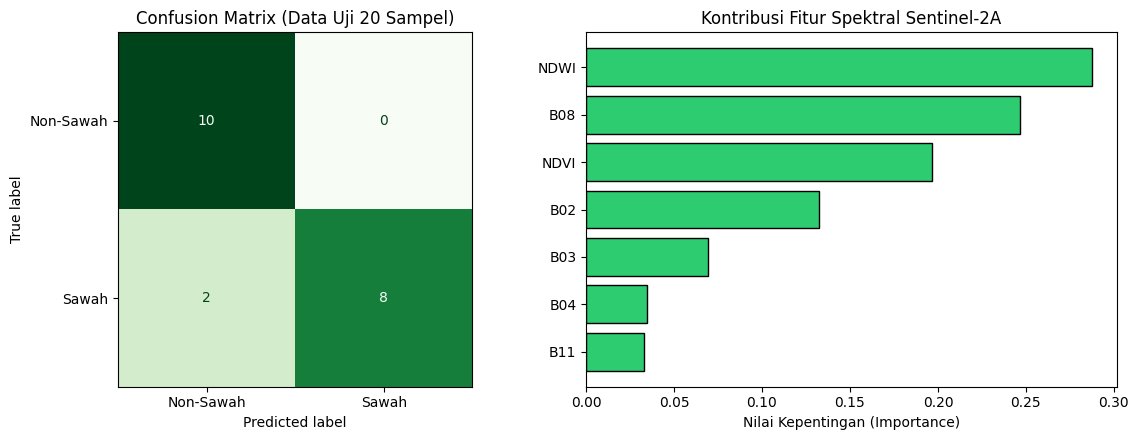

/opt/conda/envs/esa-snap/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


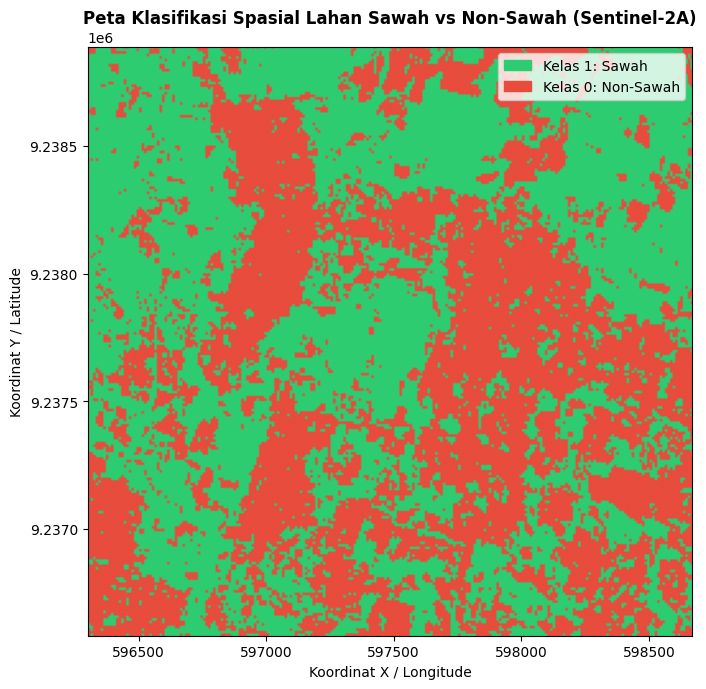

In [29]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.savefig("evaluasi_klasifikasi_sawah.png", dpi=300)
plt.show()

# ==============================================================================
# B. KLASIFIKASI SELURUH PIKSEL CITRA (.TIF) MENJADI PETA SAWAH VS NON-SAWAH
# ==============================================================================
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  img = src.read()  # Shape: (5 bands, height, width)
  profil_raster = src.profile
  bounds = src.bounds

# Ambil masing-masing band (B02, B03, B04, B08, B11)
b02, b03, b04, b08, b11 = (
    img[0].astype(float),
    img[1].astype(float),
    img[2].astype(float),
    img[3].astype(float),
    img[4].astype(float),
)

# Hitung NDVI dan NDWI untuk seluruh piksel di citra .tif
ndvi_map = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi_map = (b03 - b08) / (b03 + b08 + 1e-6)

# Susun seluruh piksel menjadi matriks 2D (baris = piksel, kolom = 7 fitur)
stack_fitur = np.stack([b02, b03, b04, b08, b11, ndvi_map, ndwi_map], axis=-1)
h, w, c = stack_fitur.shape
piksel_2d = np.nan_to_num(stack_fitur.reshape(-1, c), nan=0.0)

# Prediksi seluruh piksel menggunakan model Random Forest yang sudah dilatih
prediksi_label = model_rf.predict(piksel_2d)

# Ubah hasil prediksi ('Sawah' -> 1, 'Non-Sawah' -> 0) kembali ke ukuran gambar 2D (h, w)
peta_biner = np.where(prediksi_label == "Sawah", 1, 0).reshape(h, w)

# Tampilkan Peta Hasil Klasifikasi Spasial
plt.figure(figsize=(9, 7))
cmap_sawah = mcolors.ListedColormap(["#e74c3c", "#2ecc71"])  # Merah & Hijau
plt.imshow(
    peta_biner,
    cmap=cmap_sawah,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)

# Legenda Peta
patch_sawah = mpatches.Patch(color="#2ecc71", label="Kelas 1: Sawah")
patch_nonsawah = mpatches.Patch(color="#e74c3c", label="Kelas 0: Non-Sawah")
plt.legend(handles=[patch_sawah, patch_nonsawah], loc="upper right")
plt.title(
    "Peta Klasifikasi Spasial Lahan Sawah vs Non-Sawah (Sentinel-2A)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X / Longitude")
plt.ylabel("Koordinat Y / Latitude")
plt.tight_layout()
plt.savefig("peta_klasifikasi_raster_sawah.png", dpi=300)
plt.show()